# DJF Running Correlation (Custom Regions)\n
Notebook version of `djf_runningcorr_domainjson_layoutAC.py` using fixed `REGIONS` and inline plots (no PNG export).

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=FutureWarning)

# Keep Matplotlib cache writable in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

%matplotlib inline



In [2]:
# ----------------------------
# User config
# ----------------------------
START_YEAR = 1979
END_YEAR = 2020
WINDOWS = [15]

BASE_DATA_DIR = Path("/Users/rizzie/Academic/9_TugasAkhir/data/all_data")
WORK_DIR = Path("/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation")
CSV_DIR = WORK_DIR / "csv_domainjson"

NINO34_CSV = Path("/Users/rizzie/Academic/9_TugasAkhir/data/index/nina34.anom.csv")
CSV_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = {
    'west_indonesia': {
        'label': 'West Indonesia',
        'lat_min': -5.0,
        'lat_max': 3.0,
        'lon_min': 100.0,
        'lon_max': 115.0,
    },
    'east_indonesia': {
        'label': 'East Indonesia',
        'lat_min': -10.0,
        'lat_max': 10.0,
        'lon_min': 120.0,
        'lon_max': 140.0,
    },
    'wcmc': {
        'label': 'WCMC',
        'lat_min': -6.0,
        'lat_max': 6.0,
        'lon_min': 95.0,
        'lon_max': 137.0,
    },
}

DATASET_STYLES = {
    "MSWEP": {"color": "#1f77b4", "marker": "o"},
}
DATASET_ORDER = ["MSWEP"]
DATASET_X_JITTER = {
    "MSWEP": 0.0,
}

DATASETS = {
    "MSWEP": {
        "path": Path("/Users/rizzie/Academic/9_TugasAkhir/data/mswep"),
        "var_name": "precipitation",
        "coord_names": {"time": None, "lat": None, "lon": None},
        "unit_conversion": "none",
    },
}

TIME_CANDIDATES = ("time", "valid_time")
LAT_CANDIDATES = ("lat", "latitude", "y")
LON_CANDIDATES = ("lon", "longitude", "x")



In [3]:
# ----------------------------
# Helpers
# ----------------------------
def resolve_name(available_names, candidates):
    lookup = {name.lower(): name for name in available_names}
    for cand in candidates:
        if cand.lower() in lookup:
            return lookup[cand.lower()]
    return None


def select_precip_var(ds, dataset_name, configured_var=None):
    if configured_var is not None:
        if configured_var not in ds.data_vars:
            raise KeyError(
                f"{dataset_name}: variable '{configured_var}' not found. "
                f"Available: {list(ds.data_vars)}"
            )
        return ds[configured_var], configured_var

    candidates = []
    for var_name in ds.data_vars:
        dims_lower = [d.lower() for d in ds[var_name].dims]
        has_time = any(d in TIME_CANDIDATES for d in dims_lower)
        has_lat = any(d in LAT_CANDIDATES for d in dims_lower)
        has_lon = any(d in LON_CANDIDATES for d in dims_lower)
        if has_time and has_lat and has_lon:
            candidates.append(var_name)

    if not candidates:
        raise ValueError(
            f"{dataset_name}: no precip variable found automatically; "
            "set var_name in DATASETS."
        )

    return ds[candidates[0]], candidates[0]


def convert_precip_units(da, mode):
    if mode == "none":
        out = da
    elif mode == "m_to_mm":
        out = da * 1000.0
    elif mode == "mm_day_to_mm_month":
        out = da * da["time"].dt.days_in_month
    elif mode == "m_day_to_mm_month":
        out = da * 1000.0 * da["time"].dt.days_in_month
    else:
        raise ValueError(f"Unsupported unit conversion mode: {mode}")

    out.attrs = dict(da.attrs)
    out.attrs["units"] = "mm/month"
    out.name = da.name
    return out


def standardize_precip_da(ds, dataset_name, cfg):
    da, used_var = select_precip_var(ds, dataset_name, cfg.get("var_name"))

    available = list(da.coords) + list(da.dims)
    hints = cfg.get("coord_names", {})

    time_name = hints.get("time") or resolve_name(available, TIME_CANDIDATES)
    lat_name = hints.get("lat") or resolve_name(available, LAT_CANDIDATES)
    lon_name = hints.get("lon") or resolve_name(available, LON_CANDIDATES)

    if any(name is None for name in (time_name, lat_name, lon_name)):
        raise ValueError(
            f"{dataset_name}: unresolved coord names. coords={list(da.coords)} dims={list(da.dims)}"
        )

    rename_map = {}
    if time_name != "time":
        rename_map[time_name] = "time"
    if lat_name != "lat":
        rename_map[lat_name] = "lat"
    if lon_name != "lon":
        rename_map[lon_name] = "lon"
    if rename_map:
        da = da.rename(rename_map)

    extra_dims = [d for d in da.dims if d not in ("time", "lat", "lon")]
    for dim in extra_dims:
        da = da.isel({dim: 0}, drop=True)

    da = da.assign_coords(time=pd.to_datetime(da["time"].values))
    da = da.sortby("time")

    idx = pd.DatetimeIndex(da["time"].values)
    if idx.has_duplicates:
        _, keep_idx = np.unique(idx.values, return_index=True)
        da = da.isel(time=np.sort(keep_idx))

    lon = da["lon"]
    da = da.assign_coords(lon=((lon + 360) % 360))
    da = da.sortby("lon")

    da = convert_precip_units(da, cfg.get("unit_conversion", "none"))

    t0 = pd.Timestamp(START_YEAR - 1, 12, 1)
    t1 = pd.Timestamp(END_YEAR, 2, 28)
    da = da.sel(time=slice(t0, t1))

    print(f"{dataset_name}: var={used_var}, shape={tuple(da.shape)}, time={da['time'].size}")
    return da


def list_mswep_monthly_files(mswep_dir: Path, start_yyyymm: int, end_yyyymm: int):
    files = []
    for fp in sorted(mswep_dir.glob("*.nc")):
        stem = fp.stem
        if len(stem) != 6 or not stem.isdigit():
            continue
        yyyymm = int(stem)
        if start_yyyymm <= yyyymm <= end_yyyymm:
            files.append(fp)
    return files


def plot_domain_study_area_map(domains):
    fig = plt.figure(figsize=(11, 6.5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([94, 142, -10.5, 10.5], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="0.95")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.5, linestyle=":")

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.6, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.x_inline = False
    gl.y_inline = False

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(domains))))
    for i, (name, box) in enumerate(domains.items()):
        lon_min, lon_max = box["lon_min"], box["lon_max"]
        lat_min, lat_max = box["lat_min"], box["lat_max"]
        rect = Rectangle(
            (lon_min, lat_min),
            lon_max - lon_min,
            lat_max - lat_min,
            facecolor=colors[i],
            edgecolor="black",
            linewidth=1.2,
            alpha=0.30,
            transform=ccrs.PlateCarree(),
            zorder=3,
        )
        ax.add_patch(rect)

        label = box.get("label", name)
        ax.text(
            0.5 * (lon_min + lon_max),
            0.5 * (lat_min + lat_max),
            label,
            fontsize=9,
            fontweight="bold",
            ha="center",
            va="center",
            transform=ccrs.PlateCarree(),
            zorder=4,
        )

    ax.set_title("Study Areas")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def subset_box(da, box):
    lat_min = min(box["lat_min"], box["lat_max"])
    lat_max = max(box["lat_min"], box["lat_max"])
    lon_min = min(box["lon_min"], box["lon_max"])
    lon_max = max(box["lon_min"], box["lon_max"])

    lat0 = float(da["lat"].values[0])
    lat1 = float(da["lat"].values[-1])
    lat_slice = slice(lat_min, lat_max) if lat0 <= lat1 else slice(lat_max, lat_min)

    lon0 = float(da["lon"].values[0])
    lon1 = float(da["lon"].values[-1])
    lon_slice = slice(lon_min, lon_max) if lon0 <= lon1 else slice(lon_max, lon_min)

    return da.sel(lat=lat_slice, lon=lon_slice)


def subset_union_box(da, domains):
    lon_min = min(v["lon_min"] for v in domains.values())
    lon_max = max(v["lon_max"] for v in domains.values())
    lat_min = min(v["lat_min"] for v in domains.values())
    lat_max = max(v["lat_max"] for v in domains.values())
    return subset_box(
        da,
        {
            "lon_min": lon_min,
            "lon_max": lon_max,
            "lat_min": lat_min,
            "lat_max": lat_max,
        },
    )


def regional_monthly_mean_no_threshold(da, box):
    sub = subset_box(da, box)
    if sub.sizes.get("lat", 0) == 0 or sub.sizes.get("lon", 0) == 0:
        return pd.Series(dtype=float, name="rain_mm_month")

    ser = sub.mean(dim=("lat", "lon"), skipna=True).to_series()
    ser.index = pd.to_datetime(ser.index)
    ser = ser.sort_index()
    ser = ser.groupby(ser.index.to_period("M")).mean()
    ser.index = ser.index.to_timestamp(how="start")
    ser.name = "rain_mm_month"
    return ser


def monthly_to_djf_series_relaxed(monthly_series, start_year, end_year):
    if monthly_series.empty:
        out = pd.Series(index=np.arange(start_year, end_year + 1), dtype=float, name="djf_mean")
        out.index.name = "year"
        return out

    s = monthly_series.copy()
    s.index = pd.to_datetime(s.index)
    df = s.to_frame("value").reset_index().rename(columns={"index": "time"})
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month
    df = df[df["month"].isin([12, 1, 2])].copy()
    df["djf_year"] = np.where(df["month"] == 12, df["year"] + 1, df["year"])

    djf = df.groupby("djf_year", as_index=True)["value"].mean()
    djf = djf[(djf.index >= start_year) & (djf.index <= end_year)]

    djf.name = "djf_mean"
    djf.index.name = "year"
    return djf


def load_nino34_monthly(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    if "date" not in df.columns:
        raise ValueError(f"Nino3.4 CSV must include a 'date' column. Found: {list(df.columns)}")

    value_candidates = [c for c in df.columns if c != "date"]
    if not value_candidates:
        raise ValueError(
            f"Nino3.4 CSV must include at least one value column besides 'date'. "
            f"Found: {list(df.columns)}"
        )

    value_col = value_candidates[0]
    tmp = df[["date", value_col]].copy()
    tmp["time"] = pd.to_datetime(tmp["date"], errors="coerce")
    tmp["nino34"] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp["nino34"] = tmp["nino34"].replace([-9999, -9999.0, -99.99], np.nan)
    tmp = tmp.dropna(subset=["time"])
    tmp["time"] = tmp["time"].dt.to_period("M").dt.to_timestamp(how="start")
    tmp = tmp.groupby("time", as_index=False)["nino34"].mean().sort_values("time")

    t0 = pd.Timestamp(START_YEAR - 1, 12, 1)
    t1 = pd.Timestamp(END_YEAR, 2, 28)
    tmp = tmp[(tmp["time"] >= t0) & (tmp["time"] <= t1)]

    s = tmp.set_index("time")["nino34"]
    s.name = "nino34"
    return s


def centered_running_corr(rain_djf, nino34_djf, window, start_year, end_year):
    if window % 2 == 0:
        raise ValueError("Window length must be odd for centered running correlation.")

    half = window // 2
    rows = []

    for center in range(start_year + half, end_year - half + 1):
        y0 = center - half
        y1 = center + half

        years = pd.Index(np.arange(y0, y1 + 1), name="year")
        xw = rain_djf.reindex(years)
        yw = nino34_djf.reindex(years)

        pair = pd.concat([xw.rename("rain"), yw.rename("nino34")], axis=1).dropna()
        if len(pair) != window:
            continue

        corr = pair["rain"].corr(pair["nino34"])
        rows.append((center, corr))

    out = pd.Series(dict(rows), name="corr")
    out.index.name = "year_center"
    return out


def dataset_legend_handles():
    handles = []
    for ds in DATASET_ORDER:
        style = DATASET_STYLES[ds]
        handles.append(
            Line2D(
                [0], [0],
                linestyle="None",
                marker=style["marker"],
                markerfacecolor=style["color"],
                markeredgecolor=style["color"],
                markersize=7,
                label=ds,
            )
        )
    return handles


def plot_layout_a(window, domain_order, run_df, summary_df):
    fig, axes = plt.subplots(
        nrows=len(domain_order),
        ncols=1,
        figsize=(13, max(9, 2.2 * len(domain_order))),
        sharex=True,
        sharey=True,
    )

    if len(domain_order) == 1:
        axes = [axes]

    for ax, domain in zip(axes, domain_order):
        dsub = run_df[(run_df["window"] == window) & (run_df["domain"] == domain)]
        ssub = summary_df[(summary_df["window"] == window) & (summary_df["domain"] == domain)]
        ssub = ssub.sort_values("year_center")

        if not ssub.empty:
            ax.fill_between(
                ssub["year_center"].values,
                ssub["spread_min"].values,
                ssub["spread_max"].values,
                color="0.65",
                alpha=0.35,
                linewidth=0.0,
                zorder=1,
            )
            ax.plot(
                ssub["year_center"].values,
                ssub["median_corr"].values,
                color="black",
                linewidth=2.2,
                zorder=2,
            )

        for ds in DATASET_ORDER:
            ds_data = dsub[dsub["dataset"] == ds]
            if ds_data.empty:
                continue
            style = DATASET_STYLES[ds]
            ax.scatter(
                ds_data["year_center"].values + DATASET_X_JITTER[ds],
                ds_data["corr"].values,
                color=style["color"],
                marker=style["marker"],
                s=26,
                alpha=0.9,
                edgecolor="none",
                zorder=3,
            )

        ax.axhline(0.0, color="0.25", linewidth=0.9, linestyle="--", zorder=0)
        ax.set_ylim(-1.0, 1.0)
        ax.text(
            0.01,
            0.86,
            REGIONS[domain].get("label", domain),
            transform=ax.transAxes,
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

    axes[-1].set_xlabel("Center DJF year")
    fig.text(0.02, 0.5, "Pearson correlation (r)", va="center", rotation="vertical")
    fig.suptitle(
        f"DJF Running Correlation: Nino3.4 vs Precipitation Anomaly, "
        f"Window = {window} years, {START_YEAR} to {END_YEAR}",
        y=0.995,
    )

    fig.legend(
        handles=dataset_legend_handles(),
        labels=DATASET_ORDER,
        title="Dataset",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(0.87, 0.5),
    )

    fig.tight_layout(rect=[0.04, 0.03, 0.85, 0.98])
    plt.show()
    plt.close(fig)


def plot_layout_c(window, domain_order, summary_df):
    ssub = summary_df[summary_df["window"] == window].copy()
    years = sorted(ssub["year_center"].dropna().astype(int).unique().tolist())

    median_mat = np.full((len(domain_order), len(years)), np.nan, dtype=float)
    spread_mat = np.full((len(domain_order), len(years)), np.nan, dtype=float)

    for i, domain in enumerate(domain_order):
        r = ssub[ssub["domain"] == domain].set_index("year_center").sort_index()
        r = r.reindex(years)
        median_mat[i, :] = r["median_corr"].to_numpy()
        spread_mat[i, :] = r["spread_range"].to_numpy()

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    im1 = axes[0].imshow(
        median_mat,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-1.0,
        vmax=1.0,
        interpolation="nearest",
    )
    axes[0].set_yticks(np.arange(len(domain_order)))
    axes[0].set_yticklabels([REGIONS[d].get("label", d) for d in domain_order])
    axes[0].set_title(f"DJF Running Correlation Median (Window = {window} years)")
    for yline in np.arange(0.5, len(domain_order), 1.0):
        axes[0].axhline(yline, color="white", linewidth=0.7, alpha=0.8)
    cbar1 = fig.colorbar(im1, ax=axes[0], orientation="vertical", pad=0.02)
    cbar1.set_label("Median running correlation")

    spread_vmax = np.nanmax(spread_mat)
    if not np.isfinite(spread_vmax) or spread_vmax <= 0:
        spread_vmax = 1.0

    im2 = axes[1].imshow(
        spread_mat,
        aspect="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=spread_vmax,
        interpolation="nearest",
    )
    axes[1].set_yticks(np.arange(len(domain_order)))
    axes[1].set_yticklabels([REGIONS[d].get("label", d) for d in domain_order])
    axes[1].set_title(f"DJF Dataset Spread (max minus min), Window = {window} years")
    for yline in np.arange(0.5, len(domain_order), 1.0):
        axes[1].axhline(yline, color="white", linewidth=0.7, alpha=0.8)

    if years:
        step = max(1, len(years) // 8)
        tick_idx = np.arange(0, len(years), step)
        axes[1].set_xticks(tick_idx)
        axes[1].set_xticklabels([years[i] for i in tick_idx])
    axes[1].set_xlabel("Center DJF year")

    cbar2 = fig.colorbar(im2, ax=axes[1], orientation="vertical", pad=0.02)
    cbar2.set_label("Dataset spread (max minus min)")

    fig.suptitle(
        f"DJF Running Correlation Heatmap Summary: Nino3.4 vs Precipitation Anomaly, "
        f"Window = {window} years, {START_YEAR} to {END_YEAR}",
        y=0.995,
    )

    fig.tight_layout(rect=[0.04, 0.03, 0.98, 0.97])
    plt.show()
    plt.close(fig)



Domains: ['West Indonesia', 'East Indonesia', 'WCMC']


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


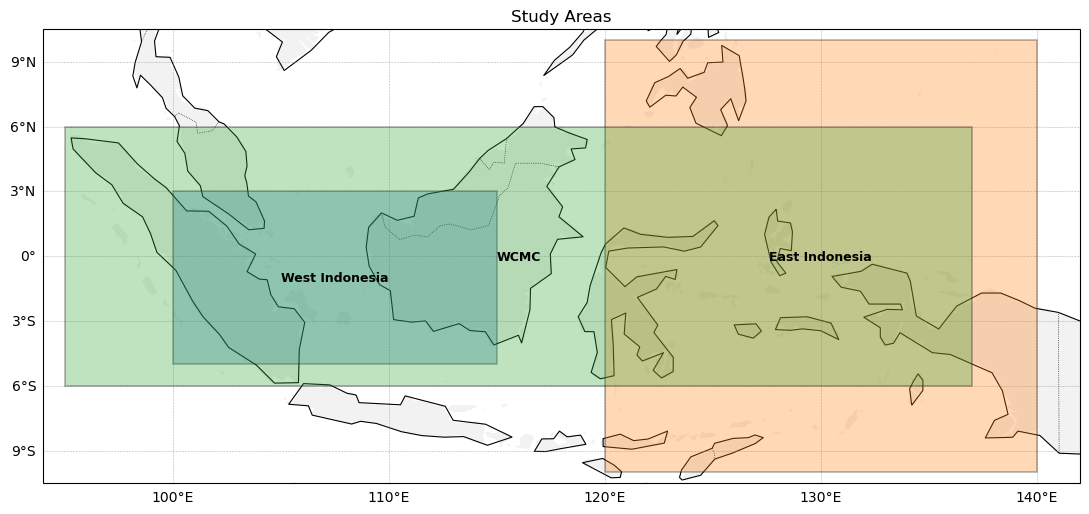

Loading Nino3.4 monthly and computing DJF Nino3.4...
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv_domainjson/nino34_djf_1979_2020.csv

Processing dataset: MSWEP
MSWEP monthly files selected: 502
MSWEP: var=precipitation, shape=(492, 1800, 3600), time=492
MSWEP: subset to domain envelope, shape=(492, 200, 450)
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv_domainjson/domain_djf_rainfall_anomalies_regions_1979_2020.csv
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv_domainjson/runningcorr_regions_tidy_1979_2020.csv
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv_domainjson/runningcorr_regions_summary_1979_2020.csv


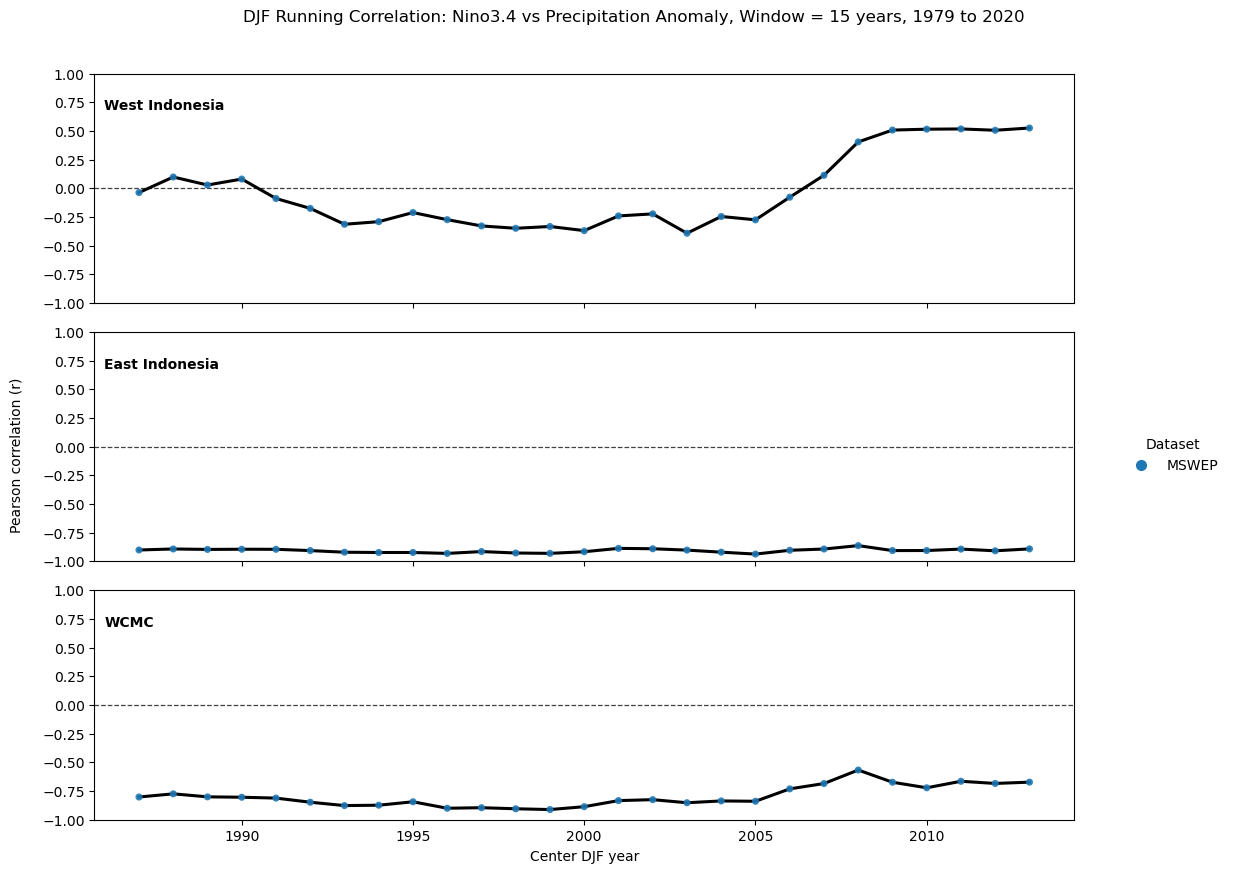

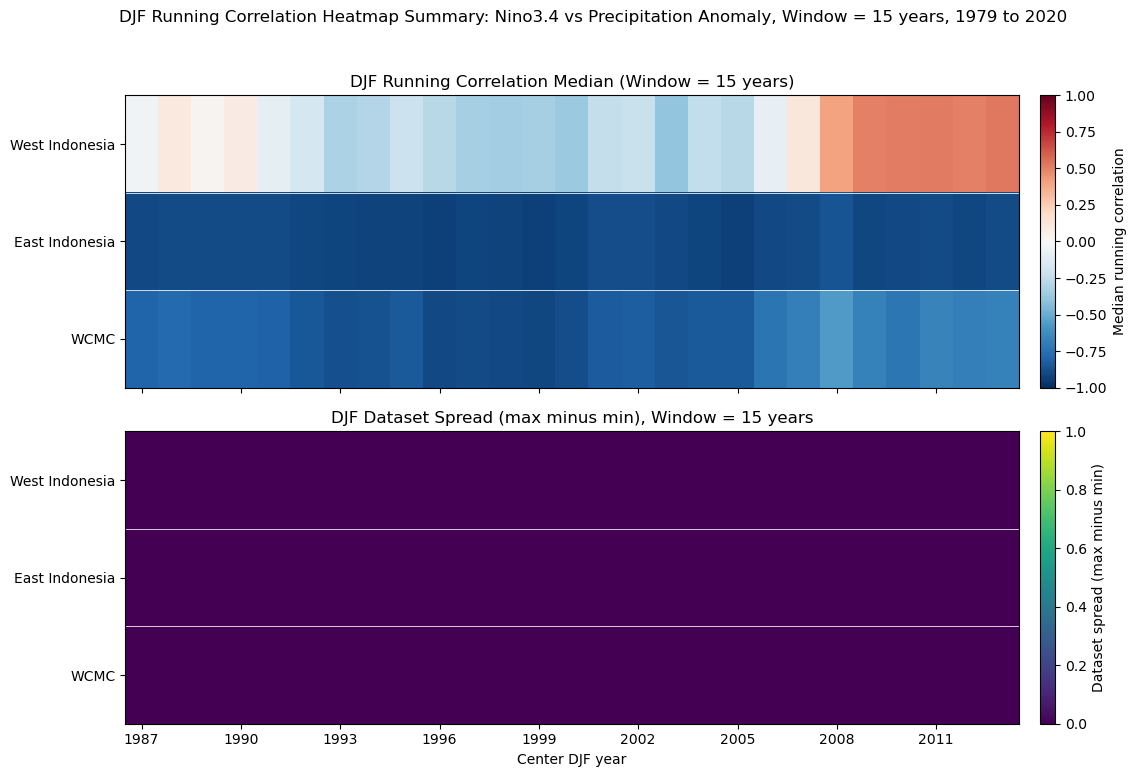

In [4]:
domains = {
    key: {
        "lon_min": float(val["lon_min"]),
        "lon_max": float(val["lon_max"]),
        "lat_min": float(val["lat_min"]),
        "lat_max": float(val["lat_max"]),
        "label": val.get("label", key),
    }
    for key, val in REGIONS.items()
}
domain_order = list(domains.keys())

print("Domains:", [domains[d]["label"] for d in domain_order])
plot_domain_study_area_map(domains)

print("Loading Nino3.4 monthly and computing DJF Nino3.4...")
nino34_monthly = load_nino34_monthly(NINO34_CSV)
nino34_djf = monthly_to_djf_series_relaxed(nino34_monthly, START_YEAR, END_YEAR).rename("nino34_djf")

nino34_csv = CSV_DIR / f"nino34_djf_{START_YEAR}_{END_YEAR}.csv"
nino34_djf.reset_index().to_csv(nino34_csv, index=False)
print("Saved:", nino34_csv)

rain_records = []
run_records = []

for dataset_name, cfg in DATASETS.items():
    print(f"\nProcessing dataset: {dataset_name}")
    if dataset_name == "MSWEP":
        mswep_dir = Path(cfg["path"])
        mswep_files = list_mswep_monthly_files(
            mswep_dir=mswep_dir,
            start_yyyymm=(START_YEAR - 1) * 100 + 12,
            end_yyyymm=END_YEAR * 100 + 12,
        )
        if not mswep_files:
            raise FileNotFoundError(
                f"No MSWEP monthly files found in {mswep_dir} for requested period."
            )
        print(f"MSWEP monthly files selected: {len(mswep_files)}")
        ds = xr.open_mfdataset(
            [str(f) for f in mswep_files],
            combine="by_coords",
            decode_times=True,
            parallel=False,
        )
    else:
        ds = xr.open_dataset(cfg["path"], decode_times=True)

    try:
        da = standardize_precip_da(ds, dataset_name, cfg)
        da = subset_union_box(da, domains)
        print(f"{dataset_name}: subset to domain envelope, shape={tuple(da.shape)}")

        for domain_name, box in domains.items():
            monthly = regional_monthly_mean_no_threshold(da, box)
            djf = monthly_to_djf_series_relaxed(monthly, START_YEAR, END_YEAR)
            anom = djf - djf.mean(skipna=True)

            for yr in sorted(djf.index.tolist()):
                rain_val = float(djf.loc[yr])
                anom_val = float(anom.loc[yr])
                if not (np.isfinite(rain_val) and np.isfinite(anom_val)):
                    continue
                rain_records.append(
                    {
                        "dataset": dataset_name,
                        "domain": domain_name,
                        "year": int(yr),
                        "djf_rain_mm_month": rain_val,
                        "djf_anomaly_mm_month": anom_val,
                    }
                )

            for w in WINDOWS:
                corr_s = centered_running_corr(anom, nino34_djf, w, START_YEAR, END_YEAR)
                for yr_center, corr in corr_s.items():
                    run_records.append(
                        {
                            "year_center": int(yr_center),
                            "window": int(w),
                            "dataset": dataset_name,
                            "domain": domain_name,
                            "corr": float(corr),
                        }
                    )
    finally:
        ds.close()

rain_df = pd.DataFrame(rain_records).sort_values(["dataset", "domain", "year"])
run_df = pd.DataFrame(run_records).sort_values(["window", "domain", "dataset", "year_center"])

rain_csv = CSV_DIR / f"domain_djf_rainfall_anomalies_regions_{START_YEAR}_{END_YEAR}.csv"
run_csv = CSV_DIR / f"runningcorr_regions_tidy_{START_YEAR}_{END_YEAR}.csv"
rain_df.to_csv(rain_csv, index=False)
run_df.to_csv(run_csv, index=False)
print("Saved:", rain_csv)
print("Saved:", run_csv)

summary_df = (
    run_df
    .groupby(["window", "domain", "year_center"], as_index=False)
    .agg(
        median_corr=("corr", "median"),
        spread_min=("corr", "min"),
        spread_max=("corr", "max"),
    )
)
summary_df["spread_range"] = summary_df["spread_max"] - summary_df["spread_min"]

summary_csv = CSV_DIR / f"runningcorr_regions_summary_{START_YEAR}_{END_YEAR}.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)

for w in WINDOWS:
    plot_layout_a(w, domain_order, run_df, summary_df)
    plot_layout_c(w, domain_order, summary_df)

